# **Misionari i kanibali**
**autor**: Ivan Tomić

# Uvod
Među mnogobrojnim problemima pretraživanja, primjer *Misionara i kanibala* zasigurno je jedan od poznatijih. Riječ je o tzv. *river crossing* slagalici u kojoj je cilj sigurno prevesti određen broj misionara i kanibala s jedne strane rijeke na drugu koristeći se jednim čamcem poštujući sljedeća pravila:
1. Ni u jednom trenutku, ni na jednoj strani rijeke, pa ni u čamcu ne smije biti strogo više kanibala od misionara.
2. Čamac ne može ploviti sam.

Najčešće se problem javlja s trima misionarima, trima kanibalima i čamcem u kojem može biti najmanje jedna, a najviše dvije osobe. Za takav slučaj optimalno rješenje ima 11 koraka. 
U ovom radu promatrat ćemo općenit slučaj s $N$ misionara, $M$ kanibala te čamcem koji prevozi najmanje $K$, a najviše $L$ osoba. 
Cilj ovoga rada jest pronaći rješenje u općenitom slučaju uporabom metode pretraživanja u širinu i dubinu te usporediti njihovu uspješnost prema broju koraka, utrošku memorije te vremenu izvođenja. (u ovisnosti o danim parametrima.)

*Napomena:* Dani parametri pripadaju skupu strogo pozitivnih cijelih brojeva.

# Opis problema
Na početku imamo $N$ misionara i $M$ kanibala na lijevoj strani rijeke. Želimo da svi sigurno dođu na desnu stranu rijeke uz dana pravila. Jasno je da slučaj $N < M$ neće imati rješenje i neće nam biti zanimljiv. Prijevozno sredstvo na raspolaganju je čamac koji može ploviti ako je u njemu između $K$ i $L$ osoba (uključivo). Također, uviđamo da slučaj $K = L$ neće nikada imati rješenje (osim kada je jasno $K \le L = N + M$, pa smo gotovi u jednom koraku jer možemo prevesti sve ljude odjednom). Kao što smo naveli u uvodu, optimalno rješenje u klasičnom slučaju $(N = M = 3, K = 1, L = 2)$ postoji te ima 11 koraka. 
Pokazalo se da u slučaju $L= 2$ za $N = M > 3$ nema rješenja, a u slučaju kad je $L \ge 4$, rješenje će postojati za bilo koji $N = M$. Postoje i različite varijante u kojima se dodaje otok na sredini rijeke, tada bilo koji broj misionara i kanibala može prijeći rijeku za $L = 2$. Međutim, nećemo se baviti tim slučajem.

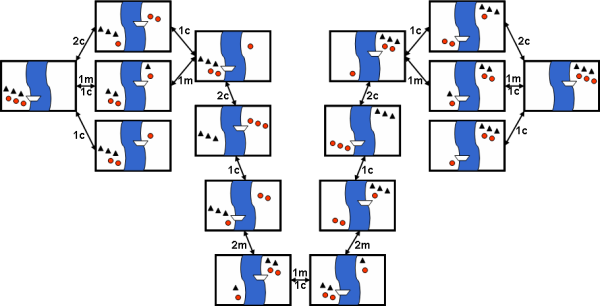

**Slika 1.**: prikaz cjelokupnog stabla (i rješenja) za $N = M = 3$, $K = 1$, $L = 2$

# Postavljanje problema
Svako stanje zapisivat ćemo s gledišta lijeve strane. Predstavit ćemo ga kao uređenu trojku $(m, c, b)$ pri čemu je:
* $m$ - trenutni broj misionara na lijevoj strani
* $c$ - trenutni broj kanibala na lijevoj strani
* $b$ - položaj broda ($1$ ako je na lijevoj strani, $0$ ako je na desnoj strani)

*Napomena:* Ako je čamac na lijevoj strani, putnici u njemu pribrajaju se brojevima misionara i kanibala na lijevoj strani i obratno.

Primijetimo da će stanje na desnoj strani tada biti jedinstveno određeno uređenom trojkom $(N - m, M - c, 1 - b)$ te lako uočavamo da je problem simetričan.
Sada početno stanje prikazujemo kao $(N, M, 1)$, a ciljno stanje kao $(0, 0, 0)$. Da bismo odredili daljnje korake, za svako stanje zanimaju nas sljedeća moguća i dopustiva stanja. Moguća stanja predstavljaju sve moguće poteze koji se mogu povući, a dopustiva stanja jesu ona koja poštuju prvo pravilo, tj. pazimo da broj kanibala nigdje nije veći od broja misionara. Dakle, stanje na lijevoj strani je dopustivo ako i samo ako je ekvivalentno stanje na desnoj strani dopustivo. Korisno nam je napisati pomoćne funkcije koje će se brinuti o tome. Nazovimo ih `problem` i `no_problem`:

In [3375]:
problem    = lambda m, c: 0 < m < c
no_problem = lambda m, c: not problem(m, c) and not problem(N - m, M - c)

Jasno, funkcija `problem` vraća $1$, ako na lijevoj strani nije ispoštivano pravilo, a funkcija `no_problem` vraća $1$ ako je stanje dopustivo, tj. ispoštivali smo pravilo i na lijevoj i na desnoj strani.

Sada možemo definirati sljedeća moguća i dopustiva stanja za neko stanje. Nazovimo funkciju `next_states`: 

In [3379]:
def next_states(state):
    m, c, b = state
    if b == 1:
        return { (m - mb, c - cb, 0) for mb in range(m + 1)
                                 for cb in range(c + 1)
                                 if K <= mb + cb <= L and no_problem(m - mb, c - cb) and (mb >= cb or mb == 0) 
               }
    else:
        return { (m + mb, c + cb, 1) for mb in range(N - m + 1)
                                 for cb in range(M - c + 1)
                                 if K <= mb + cb <= L and no_problem(m + mb, c + cb) and (mb >= cb or mb == 0)
               }

Dakle, za neko stanje, funkcija vraća skup svih sljedećih stanja koja su i moguća i dopustiva. Varijable `mb` i `cb` označavaju promjenu broja misionara, odnosno kanibala na lijevoj strani. Tri uvjeta paze, redom, na kapacitet čamca, dopustivost novog (sljedećeg) stanja i da se u brodu ne prevozi više kanibala od misionara (osim ako uopće misionari nisu u čamcu.)

Možemo isprobati rad prethodno napisane funkcije. 

In [3382]:
N = 4
M = 4
K = 1
L = 3

state = (N, M, 1)
print(next_states(state))

{(3, 3, 0), (4, 1, 0), (4, 2, 0), (4, 3, 0)}


# Algoritmi pretraživanja #
Napokon prelazimo na same funkcije `bfs` i `dfs`. Prije toga, napišimo još jednu pomoćnu funkciju `path_to`.

In [3385]:
def path_to(state, Parent):
    p = Parent.get(state)
    if p == state:
        return [state]
    return path_to(p, Parent) + [state]

In [3387]:
def bfs(start, goal, next_states):
    Frontier = [ start ]
    Visited  = set()
    Parent   = { start: start }
    while len(Frontier) > 0:
        s = Frontier.pop(0)
        if s == goal:
            return path_to(goal, Parent)
        if s not in Visited:
            Visited.add(s)
            for ns in next_states(s):
                if ns not in Visited:
                    Frontier.append(ns)
                    Parent[ns] = s

In [3389]:
def dfs(start, goal, next_states):
    Frontier = [ start ]
    Visited  = set()
    Parent   = { start: start }
    while len(Frontier) > 0:
        s = Frontier.pop()
        if s == goal:
            return path_to(goal, Parent)
        if s not in Visited:
            Visited.add(s)
            for ns in next_states(s):
                if ns not in Visited:
                    Frontier.append(ns)
                    Parent[ns] = s

Objasnimo rad napisanih funkcija. Funkcije `bfs` i `dfs` kao argumente primaju početno i završno stanje te skup `next_states`.  Lista `Frontier` sprema na početku početno stanje koje je ujedno korijen stabla. Ta lista u prvom slučaju predstavlja red, a u drugom slučaju stog. Prvo provjerimo je li dano stanje već ciljno. Ako nije, provjeravamo je li posjećeno. Tu informaciju sadržava skup `Visited`. Ako nije posjećeno, stavljamo ga u posjećene i gledamo sva sljedeća stanja. Ako ona nisu posjećena, dodajemo ih u našu listu i u rječnik `Parent` spremamo za svako dijete njegova roditelja. S obzirom na to da stanje nije posjećeno, sigurni smo da nećemo spremiti pod dva ista djeteta, dva različita roditelja. Jasno, korijen stabla nema roditelja, pa smo to naznačili tako da je on sam sebi roditelja. To će nam biti korisno za funkciju `path_to`. Kako smo u listu `Frontier` dodali sva sljedeća neposjećena stanja, sljedeće stanje koje posjećujemo ovisi o tome kojim načinom pretražujemo. Tu jedinu razliku u kodu između tih dviju funkcija primjećujemo u retku:

In [3392]:
#s = Frontier.pop(0)
#s = Frontier.pop()

U prvom slučaju ako uzimamo prvi element liste, lista je zapravo red jer pretražujemo svu djecu od početnog čvora, a u drugom slučaju idemo u dubinu stabla skroz dok ne dođemo do ciljnog stanja ili već nekog posjećenog stanja. U slučaju da smo pretražili sve elemente i nismo došli do ciljnog stanja, funkcije vraćaju *None* (nema *returna*).

Funkcija `path_to` rekurzivno sprema svaki korak rješenja. Prekida se upravo u trenutku kada dođemo do korijena stabla, tj. kad je dano stanje jednako roditelju što smo odmah zabilježili u prethodno napisanim funkcijama. Te funkcije, dakle, u slučaju postojanja rješenja, odmah vraćaju i put kojim su došli do rješenja. 

*Napomena:* Broj koraka upravo je duljina dobivene liste koraka manje jedan. (korak je promjena iz jednog stanje u drugo)

Sada možemo isprobati rad napisanih funkcija. 

In [3396]:
N = 4
M = 4
K = 1
L = 4

start = (N, M, 1)
goal = (0, 0, 0)

Path1 = bfs(start, goal, next_states)
Path2 = dfs(start, goal, next_states)

if Path1 == None or Path2 == None: print('Nema rješenja')
else:
    print('Broj koraka rješenja metodom bfs iznosi:', len(Path1) - 1) 
    #print(Path1)
    print('Broj koraka rješenja metodom dfs iznosi:', len(Path2) - 1) 
    #print(Path2)

Broj koraka rješenja metodom bfs iznosi: 5
Broj koraka rješenja metodom dfs iznosi: 9


Uočimo da npr. za $M = N = L = 4$ i $K = 1$, broj koraka rješenja metodom bfs iznosi 5, a metodom dfs 9. Lako se pokaže da će funkcija `bfs` uvijek naći optimalno rješenje što se broja koraka tiče, ali vjerojatnije je da će funkcija `dfs` brže doći do rješenja. Testirajmo našu pretpostavku za taj primjer. Izmjerimo vrijeme izvršenja funkcije.

In [3399]:
from time import*

N = 20
M = 20
K = 2
L = 4

pocetak = time()
Path = dfs(start, goal, next_states)
sleep(3)
kraj = time()
print('Broj sekundi potreban za izvršenje dfs: {:.4f} s'.format(kraj - pocetak))

pocetak = time()
Path = bfs(start, goal, next_states)
sleep(3)
kraj = time()
print('Broj sekundi potreban za izvršenje bfs: {:.4f} s'.format(kraj - pocetak))

Broj sekundi potreban za izvršenje dfs: 3.0075 s
Broj sekundi potreban za izvršenje bfs: 3.0032 s


Provevši mjerenje pet puta. dobivamo da je prosječno vrijeme izvođenja za `bfs` 0,0071 sekundi, a za `dfs` 0,0027 sekundi. Premda su razlike vrlo male, postoje i trebamo uzeti u obzir činjenicu da je taj primjer vrlo jednostavan. Stoga ćemo provesti još neka mjerenja.

*Napomena:* Korištenje funkcije sleep(3), tj. 3 sekunde odmaka davalo mi je veću točnost, osobito kod manjih primjera.

Alternativno, mogli smo koristiti i *%timeit*:

In [3401]:
print('Vrijeme potrebno za izvršenje funkcije dfs:') 
%timeit dfs(start, goal, next_states)
print('Vrijeme potrebno za izvršenje funkcije bfs:')
%timeit bfs(start, goal, next_states)

Vrijeme potrebno za izvršenje funkcije dfs:
233 μs ± 28.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Vrijeme potrebno za izvršenje funkcije bfs:
658 μs ± 45.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Prvo ćemo za fiksne $K = 2$ i $L = 4$, promotriti slučaj $N = M$. Za svaki slučaj mjerili smo tri puta i uzeli prosječno vrijeme u sekundama. Usput ćemo zabilježiti i broj koraka danog rješenja.

*Napomena:* Kao što je rečeno još u uvodu, za $L \ge 4$ znamo da će rješenje postojati za bilo koji $M = N$. Zato smo uzeli takve $K$ i $L$.

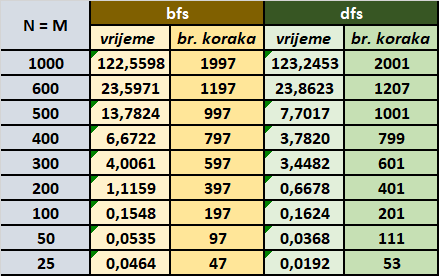

Možemo primijetiti da je u gotovo svim slučajevima funkcija `dfs` brža, ali, jasno, što se broja koraka tiče, `bfs` je tu nenadmašiva jer uvijek daje optimalno rješenje, no `dfs` nudi relativno dobro rješenje u pogledu broja koraka te uz činjenicu da je brža.

Promotrimo sada za slučaj $N > M$. Parametre $K$ i $L$ i dalje ne mijenjamo, a $M$ ćemo fiksirati na $20$.

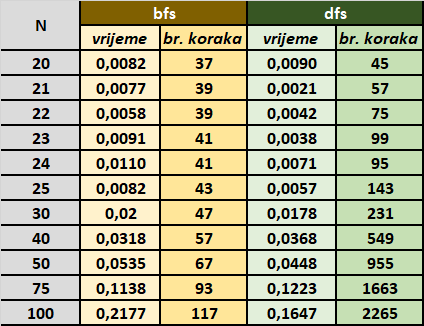

Možemo primijetiti kako broj koraka pri dubokom pretraživanju strelovito raste i zasigurno bi za neke veće primjere rekurzija (u funkciji `path_to`) dosegnula svoj maksimum, tzv. *maximum depth of recursion*. Upravo o tome i ovisi prostorna složenost funkcije `dfs`, dakle u najgorem slučaju imali bismo stablo gdje svaki vrh ima točno jedno dijete (izuzev zadnjeg koji je list). Prostorna složenost bila bi $O(V)$ gdje je V broj vrhova. Slično zaključimo da bi to bila i prostorna složenost funkcije `bfs` jer bismo u najgorem slučaju morali proći po svim vrhovima. (potezima) Dakle, u redu bismo imali spremljeno sve vrhove.

Što se vremena izvršavanja tiče, `dfs` je i dalje u većini slučajeva brži, premda razlike nisu osjetne na manjim primjerima dok je broj koraka značajno različit. Stoga bi u ovom slučaju odgovor na pitanje koja je funkcija bolja ovisio o tome što nam je važnije: doći do rješenja ili doći do optimalnog rješenja. 

Preostaje nam još promotriti situaciju za fiksne $N$ i $M$ te varijabilne $K$ i $L$. Postavit ćemo $N = M = 100$, mjerimo vrijeme i bilježimo korake. Dobivamo sljedeću tablicu:

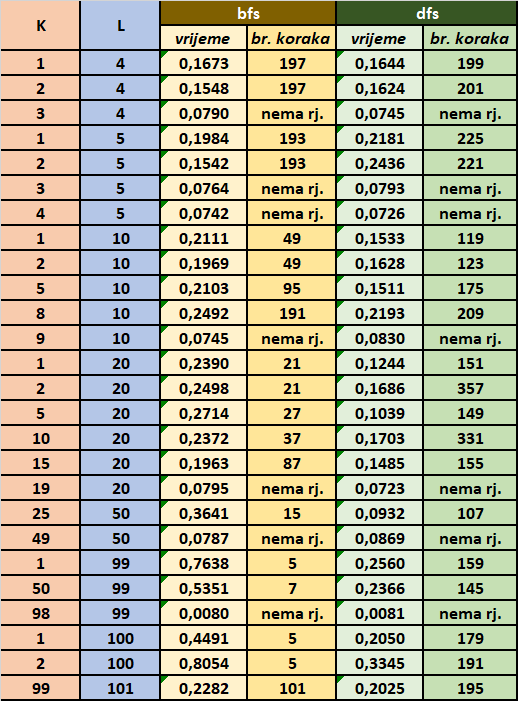

Ono što zasigurno primjećujemo da što je veći raspon čamca, optimalno rješenje ima manje koraka. Ipak, nemojmo se polakomiti jer `bfs` pretraži svu djecu od čvora i tek onda ide na prvo dijete i njegovu djecu. Primjećujemo da što je razlika između $K$ i $L$ manja, to je razlika brojeva koraka rješenja od ovih dviju funkcija manja. Zanimljivo je primijetiti da u slučajevima $L - K = 1$ nema rješenja i funkcije vremenski podjednako riješe taj slučaj, odnosno zaključe da nema rješenja. To nam je ujedno i najgori slučaj za obje funkcije jer tada one moraju proći po svim elementima stabla da bi zaključile da nema rješenja. 

Promotrimo još jednu verziju funkcije pretraživanja u širinu. Nazovimo je `bfs2`:

In [3350]:
def bfs2(start, goal, next_states):
    Frontier = { start }
    Visited  = set()
    Parent   = { start: start }
    while len(Frontier) > 0:
        NewFrontier = set()
        for s in Frontier:
            for ns in next_states(s):
                if ns not in Visited and ns not in Frontier: 
                    NewFrontier.add(ns)
                    Parent[ns] = s
                    if ns == goal:
                        return path_to(goal, Parent)
        Visited |= Frontier
        Frontier = NewFrontier

#bfs2(start, goal, next_states)

Primijetimo da ovdje imamo dva skupa `Frontier` i `New Frontier` te zapravo nakon što prođemo po svim sljedećim stanjima od `s`, sva neposjećena stanja spremamo u `New Frontier` koji zatim postaje novi `Frontier`, tj. idemo jednu razinu više u dubinu. Činjenica da je prosječna vremenska složenost operacija sa skupom $O(1)$, a operacija s listom $O(n)$, očekujemo poboljšanje.

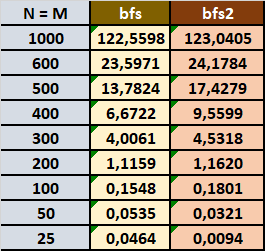 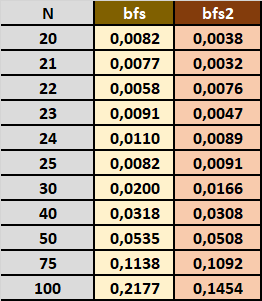 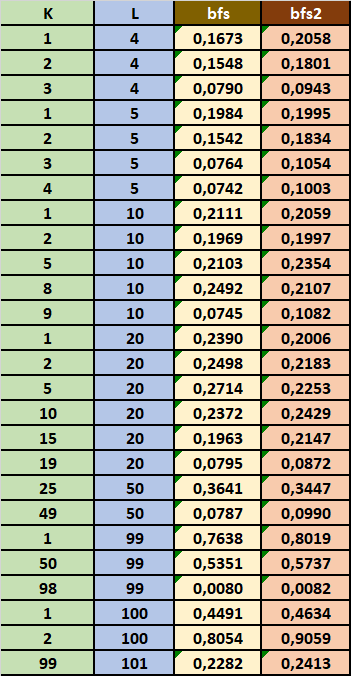

Kao što možemo iščitati iz tablice, funkcija funkcija `bfs2` pokazala se vremenski bržom u drugom slučaju ($N > M$). Zanimljiv je i prvi slučaj gdje je za manje brojeve funkcija `bfs2` bila brža, a za veće brojeve dogodio se obrat. Iako nismo dobili neku značajniju promjenu, vjerojatnije bi se razlika osjetila na puno većim primjerima.

Prokomentirajmo još potrošnju memorije. Funkcije `dfs` i `bfs` upotrebljavaju listu `Frontier`, skup `Visited` i rječnik `Parent`. Funkcija `bfs2` upotrebljava još i skup `NewFrontier`, ali umjesto liste upotrebljava skup (`Frontier`). Zanima nas koliko memorije zauzimaju ovisno o parametrima te ćemo posebno brojiti potrošnju memoriju za svaki od njih i spremati redom u varijable `sumaF`, `sumaV`, `sumaP`, `sumaNF` te ćemo prije kraja izvršenja funkcije (prije samog returna ili nakon izvršenja while petlje) ispisati ukupnu potrošnju. Ispise stavimo na oba mjesta jer će za neke slučajeve funkcije doći do rješenja, a za neke neće. Svaki put kada dodajemo nove vrijednosti u `Frontier`, `Visited`, `Parent` ili `NewFrontier` ažuriramo stanje varijabli suma. 
Prošireni kod izgleda ovako:

In [3404]:
import sys
N = 25
M = 20
K = 2
L = 4
start = (N, M, 1)
goal = (0, 0, 0)


def bfs(start, goal, next_states):
    Frontier = [ start ]
    Visited  = set()
    Parent   = { start: start }
    sumaF = sys.getsizeof(Frontier)
    sumaV = sys.getsizeof(Visited)
    sumaP = sys.getsizeof(Parent)
    while len(Frontier) > 0:
        s = Frontier.pop(0)
        if s == goal:
            print('Ukupna potrošnja:', sumaF + sumaV + sumaP)
            print('Posebno Frontier:', sumaF)
            print('Posebno Visited:', sumaV)
            print('Posebno Parent:', sumaP)
            return path_to(goal, Parent)
        if s not in Visited:
            Visited.add(s)
            sumaV += sys.getsizeof(s)
            for ns in next_states(s):
                if ns not in Visited:
                    Frontier.append(ns)
                    Parent[ns] = s
                    sumaF += sys.getsizeof(ns)
                    sumaP = sys.getsizeof(Parent)
    print('Ukupna potrošnja:', sumaF + sumaV + sumaP)
    print('Posebno Frontier:', sumaF)
    print('Posebno Visited:', sumaV)
    print('Posebno Parent:', sumaP)
        
def dfs(start, goal, next_states):
    Frontier = [ start ]
    Visited  = set()
    Parent   = { start: start }
    sumaF = sys.getsizeof(Frontier)
    sumaV = sys.getsizeof(Visited)
    sumaP = sys.getsizeof(Parent)
    while len(Frontier) > 0:
        s = Frontier.pop()
        if s == goal:
            print('Ukupna potrošnja:', sumaF + sumaV + sumaP)
            print('Posebno Frontier:', sumaF)
            print('Posebno Visited:', sumaV)
            print('Posebno Parent:', sumaP)
            return path_to(goal, Parent)
        if s not in Visited:
            Visited.add(s)
            sumaV += sys.getsizeof(s)
            for ns in next_states(s):
                if ns not in Visited:
                    Frontier.append(ns)
                    Parent[ns] = s
                    sumaF += sys.getsizeof(ns)
                    sumaP = sys.getsizeof(Parent)      
    print('Ukupna potrošnja:', sumaF + sumaV + sumaP)
    print('Posebno Frontier:', sumaF)
    print('Posebno Visited:', sumaV)
    print('Posebno Parent:', sumaP)

def bfs2(start, goal, next_states):
    Frontier = { start }
    Visited  = set()
    Parent   = { start: start }
    sumaNF = 0
    sumaF = sys.getsizeof(Frontier)
    sumaV = sys.getsizeof(Visited)
    sumaP = sys.getsizeof(Parent)
    while len(Frontier) > 0:
        NewFrontier = set()
        sumaNF = sys.getsizeof(NewFrontier)
        for s in Frontier:
            for ns in next_states(s):
                if ns not in Visited and ns not in Frontier: 
                    NewFrontier.add(ns)
                    sumaNF += sys.getsizeof(ns)
                    Parent[ns] = s
                    sumaP = sys.getsizeof(Parent) 
                    if ns == goal:
                        print('Ukupna potrošnja:', sumaNF + sumaF + sumaV + sumaP)
                        print('Posebno New Frontier:', sumaNF)
                        print('Posebno Frontier:', sumaF)
                        print('Posebno Visited:', sumaV)
                        print('Posebno Parent:', sumaP)
                        return path_to(goal, Parent)
        Visited |= Frontier
        Frontier = NewFrontier
        sumaV = sys.getsizeof(Visited)
        sumaF += sys.getsizeof(Frontier)
    print('Ukupna potrošnja:', sumaNF + sumaF + sumaV + sumaP)
    print('Posebno New Frontier:', sumaNF)
    print('Posebno Frontier:', sumaF)
    print('Posebno Visited:', sumaV)
    print('Posebno Parent:', sumaP)    

print('Funkcija bfs:')
Path1 = bfs(start, goal, next_states)
print()
print('Funkcija dfs:')
Path2 = dfs(start, goal, next_states)
print()
print('Funkcija bfs2:')
Path3 = bfs2(start, goal, next_states)



Funkcija bfs:
Ukupna potrošnja: 84272
Posebno Frontier: 55680
Posebno Visited: 19288
Posebno Parent: 9304

Funkcija dfs:
Ukupna potrošnja: 68592
Posebno Frontier: 45504
Posebno Visited: 13784
Posebno Parent: 9304

Funkcija bfs2:
Ukupna potrošnja: 48784
Posebno New Frontier: 280
Posebno Frontier: 30792
Posebno Visited: 8408
Posebno Parent: 9304


Sada ćemo dodati tablice s istim vrijednostima parametara kao i kod mjerenja vremena i broja koraka. Dobivamo sljedeće rezultate:

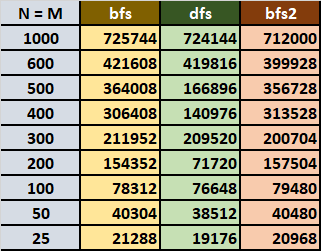
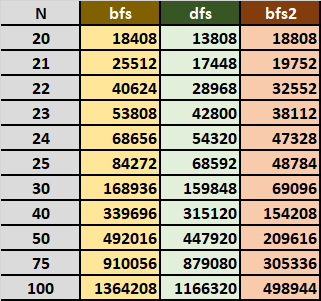
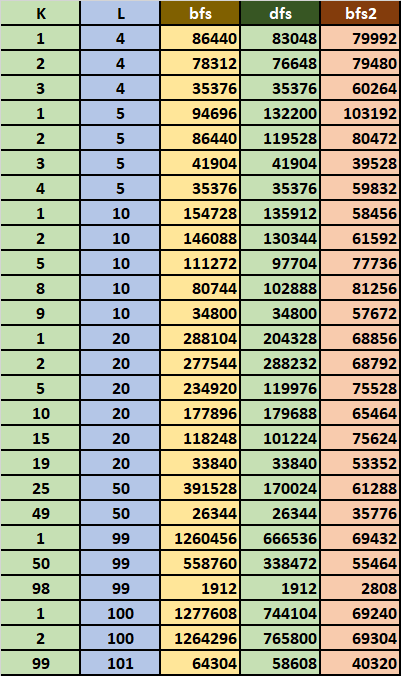

U prvoj i drugoj tablici možemo primijetiti kako `dfs` zauzima manje memorije od `bfs`, ali funkcija `bfs2` zauzima za veće parametre puno manje memorije od obiju funkcija. Zapravo se jedino u slučajevima gdje nema rješenja, funkcija `bfs2` zauzme najviše memorije dok preostale dvije funkcije zauzmu jednako memorije. U trećoj tablici također možemo primijetiti da za neke slučajeve `dfs` ipak zauzme više memorije od `bfs`. Generalno možemo zaključiti

Za kraj, spomenimo još da se starija varijanta ovog problema javlja još u $9.$ stoljeću. Umjesto misionara i kanibala imamo bračne parove. Cilj je jednak, prevesti s jedne strane na drugu sve bračne parove. Problem se još naziva i problem ljubomornih muževa. Naime, nijedna žena ne može prelaziti sama niti biti na drugoj strani rijeke u prisustvu drugih muškaraca. Optimalno rješenje problema za slučaj kad imamo tri bračna para i čamac koji može prevesti do $2$ ljudi iznosi $11$ koraka, isto kao i u slučaju kad imamo tri misionara i tri kanibala. Također, ako računamo žena u čamcu (ako je sama) ne pripada nijednoj obali, nego je sama na svoju ruku, onda bi optimalno rješenje imalo $9$ koraka.

# Zaključak #
Za dani problem ponudili smo dva algoritma za traženje rješenja. Funkcija `bfs` zbog načina pretraživanja daje nam optimalno rješenje u svim slučajevima. Vremenski je funkcija `dfs` bila bolja u većini slučajeva, ali davala je puno kompliciranija rješenja osobito u slučaju $N > M$. Druga inačica funkcije za pretraživanje u širinu pokazala se vremenski boljom u većini slučajeva kao što je i prednjačila u potrošnji memoriju u većini slučajeva. Iz svih mjerenja i danih podataka, mogli bismo zaključiti da nam je `bfs2` bolja verzija za pretraživanje u širinu od `bfs` glede vremena i potrošnje memorije (Dodajmo činjenicu da skup u konačnici zauzme manje memorije od liste). U načelu, način je pretraživanja u dubinu dao bolje vremenske rezultate od pretraživanja u širinu. 
Dakle, ovisno o tome što nam je važnije - količina memorije, brzina izvođenja ili optimalnost rješenja - izabrali bismo način pretraživanja u širinu ili u dubinu, ali oba pretraživanja bi nas dovela do rješenja.

# Izvori #
* Materijali s kolegija *Umjetna inteligencija*
* https://en.wikipedia.org/wiki/Missionaries_and_cannibals_problem
* https://www.geeksforgeeks.org/missionaries-and-cannibals/
* https://www.aiai.ed.ac.uk/~gwickler/missionaries.html
* https://techsauce.medium.com/time-complexity-and-space-complexity-of-dfs-and-bfs-algorithms-671217e43d58